# Chapter 8: Non-Euclidean geometry

Source orientation: printed pages 174-212, physical PDF pages 184-222, sections 8.1-8.9. This notebook is an original standalone lesson. The source span was used to choose topics, terminology, and order only; the prose, diagrams, computations, labs, and checks here are newly authored for this course.

## Chapter goal

Build the hyperbolic plane from the projective line. The real projective line becomes the boundary, real linear fractional transformations become half-plane transformations, and the visible geometry is carried by three inspectable structures: orthogonal circles and vertical lines as geodesics, angle-preserving Mobius maps, and a cross-ratio-derived distance.

## Computational translation guide

| Book idea | Computational object used here | What to inspect |
| --- | --- | --- |
| Boundary projective line $\mathbb{RP}^1$ | Real axis plus the point at infinity | Endpoints of half-plane geodesics live on the boundary, not inside the plane. |
| Non-Euclidean lines | Vertical rays and semicircles orthogonal to the real axis | Many geodesics through one point can miss a fixed geodesic. |
| Half-plane extension of $x \mapsto (ax+b)/(cx+d)$ | Real $2\times 2$ matrices; determinant decides holomorphic or reflected extension | Positive determinant preserves orientation; negative determinant uses complex conjugation. |
| Reflection | Anti-Mobius map fixing a geodesic pointwise | A vertical reflection, a circle inversion, and their products generate translations, dilations, and half-turns. |
| Distance | $d_H(z,w)=\operatorname{arcosh}\left(1+\frac{|z-w|^2}{2\operatorname{Im}z\operatorname{Im}w}\right)$ | On the $y$-axis this reduces to $|\log(q/p)|$. |
| Disk models | Cayley transform to the Poincare disk, then radial projection to the Klein disk | The Poincare disk preserves angles; the Klein disk straightens geodesics into chords. |

## Chapter-specific storyboard

1. `half-plane-geodesics-and-parallels.png`: half-plane lines and visible failure of the Euclidean parallel axiom.
2. `half-plane-disk-model-comparison.png`: the same geodesics in the upper half-plane, Poincare disk, and Klein disk.
3. `mobius-conformal-grid.png` plus `mobius-generator-lab.html`: real-coefficient Mobius transformations applied to a grid and to geodesics.
4. `circle-reflection-and-factorization.png` and `reflection-factorization-proof-map.png`: reflections in geodesics, products of reflections, and the theorem route from projective involutions to at most three reflections.
5. `distance-heatmap-and-horocycles.png` plus `distance-model-lab.html`: distance level sets, equally spaced points on the vertical ruler, and disk/half-plane distance agreement.
6. `chapter-08-invariants.json`, `chapter-08-storyboard.json`, and CSV tables: numeric and symbolic checks for distance, angle, cross-ratio, model comparison, artifact integrity, and reflection factorizations.

## Library routing

Matplotlib is used for durable 2D geometric diagrams because this chapter is mostly planar incidence, angle, and curve geometry. Plotly is used for standalone transformation and distance labs where toggling or hovering over model data clarifies the action. SymPy checks the algebraic invariants behind Mobius maps and cross-ratio preservation. NetworkX renders the proof dependency graph for the reflection factorization theorem. NumPy supplies the direct complex-coordinate computations.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys, math, json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if candidate.name == "The-Four-Pillars-of-Geometry" and (candidate / "AGENTS.md").exists():
            return candidate
        nested = candidate / "The-Four-Pillars-of-Geometry"
        if nested.exists() and (nested / "AGENTS.md").exists():
            return nested
    raise RuntimeError("Could not locate The-Four-Pillars-of-Geometry root")

BOOK_ROOT = find_book_root(Path.cwd().resolve())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, image_stats, save_json, save_table

CHAPTER_KEY = "chapter-08-non-euclidean-geometry"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / CHAPTER_KEY
for folder in ["figures", "html", "checks", "tables"]:
    (ARTIFACT_ROOT / folder).mkdir(parents=True, exist_ok=True)

FIGURES = {
    "geodesics": ARTIFACT_ROOT / "figures" / "half-plane-geodesics-and-parallels.png",
    "models": ARTIFACT_ROOT / "figures" / "half-plane-disk-model-comparison.png",
    "mobius_grid": ARTIFACT_ROOT / "figures" / "mobius-conformal-grid.png",
    "reflections": ARTIFACT_ROOT / "figures" / "circle-reflection-and-factorization.png",
    "proof_map": ARTIFACT_ROOT / "figures" / "reflection-factorization-proof-map.png",
    "distance": ARTIFACT_ROOT / "figures" / "distance-heatmap-and-horocycles.png",
}
HTML = {
    "mobius_lab": ARTIFACT_ROOT / "html" / "mobius-generator-lab.html",
    "distance_lab": ARTIFACT_ROOT / "html" / "distance-model-lab.html",
}
CHECKS = {
    "storyboard": ARTIFACT_ROOT / "checks" / "chapter-08-storyboard.json",
    "invariants": ARTIFACT_ROOT / "checks" / "chapter-08-invariants.json",
    "manifest": ARTIFACT_ROOT / "checks" / "artifact-manifest.json",
}
TABLES = {
    "distance_samples": ARTIFACT_ROOT / "tables" / "distance-samples.csv",
    "mobius_samples": ARTIFACT_ROOT / "tables" / "mobius-samples.csv",
}
PALETTE = {"ink":"#1f2933","blue":"#1f77b4","orange":"#e07a2f","green":"#2e8b57","red":"#c74343","purple":"#6f5bd7","gold":"#c7971d","gray":"#75808a","paper":"#fffdf7"}

storyboard = [
    {"artifact":"figures/half-plane-geodesics-and-parallels.png","concept":"upper half-plane geodesics and parallel axiom failure","representation":"Matplotlib half-plane diagram","inspection_target":"vertical lines and boundary-orthogonal semicircles through one point that miss a fixed geodesic","validation":"geodesic endpoints lie on the real boundary and plotted semicircles contain the marked point"},
    {"artifact":"figures/half-plane-disk-model-comparison.png","concept":"upper half-plane, Poincare disk, and Klein disk models","representation":"Matplotlib model comparison","inspection_target":"Poincare geodesics remain boundary-orthogonal circles while Klein geodesics become chords","validation":"Cayley distance agreement and Klein collinearity residual"},
    {"artifact":"figures/mobius-conformal-grid.png and html/mobius-generator-lab.html","concept":"real Mobius transformations of the half-plane","representation":"conformal grid plus Plotly generator lab","inspection_target":"grid angles are locally preserved while geodesics move to geodesics","validation":"finite-difference angle check and imaginary-part formula"},
    {"artifact":"figures/circle-reflection-and-factorization.png and figures/reflection-factorization-proof-map.png","concept":"reflections, products of reflections, and three-reflection theorem scaffold","representation":"reflection diagram plus NetworkX proof graph","inspection_target":"anti-Mobius reflections fix a geodesic; two such reflections yield familiar Mobius maps","validation":"reflection involution and matrix factorization checks"},
    {"artifact":"figures/distance-heatmap-and-horocycles.png and html/distance-model-lab.html","concept":"cross-ratio distance and model-consistent heatmaps","representation":"Matplotlib heatmaps plus Plotly hover lab","inspection_target":"distance to the boundary grows without bound and equal ratios on the y-axis give equal steps","validation":"axis log-distance, additivity, symmetry, and Mobius invariance checks"},
]
save_json(storyboard, ARTIFACT_ROOT, "checks", "chapter-08-storyboard.json")
print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT}")


## 1. Lines in the upper half-plane

The half-plane model keeps the real projective line as the boundary. Its lines are not arbitrary Euclidean curves: they are exactly the vertical rays and the semicircles that meet the boundary at right angles. This is already enough to see the non-Euclidean parallel behavior. Fix a vertical geodesic and choose a point away from it. There is not just one geodesic through the point that avoids the fixed line; there are many.

The diagram below is deliberately low-tech. The important observation is not a formula but a shape constraint: every geodesic has two boundary ends, and avoiding a fixed geodesic can happen by choosing both ends on the same side of it or by sharing the ideal endpoint at infinity.


In [2]:
def setup_halfplane_axes(ax, xlim=(-3, 3.2), ylim=(-0.15, 3.2), title=None):
    ax.set_facecolor(PALETTE["paper"])
    ax.axhline(0, color=PALETTE["ink"], lw=1.8, linestyle=(0, (5, 4)))
    ax.fill_between([xlim[0], xlim[1]], [0, 0], [ylim[1], ylim[1]], color="#f9f4e8", zorder=-10)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e6decf", lw=0.7, alpha=0.75)
    ax.set_xlabel("Re z"); ax.set_ylabel("Im z")
    if title: ax.set_title(title, color=PALETTE["ink"], weight="bold", pad=12)

def semicircle_points(center, radius, n=260, eps=0.012):
    theta = np.linspace(eps, math.pi - eps, n)
    return center + radius * np.cos(theta) + 1j * radius * np.sin(theta)

def geodesic_through_points(z, w, n=260):
    if abs(z.real - w.real) < 1e-10:
        y = np.linspace(0.04, max(z.imag, w.imag) * 1.8 + 0.5, n)
        return z.real + 1j * y
    center = (abs(w) ** 2 - abs(z) ** 2) / (2 * (w.real - z.real))
    radius = math.sqrt((z.real - center) ** 2 + z.imag ** 2)
    return semicircle_points(center, radius, n=n)

def plot_complex_curve(ax, z, color, lw=2.2, label=None, alpha=1.0, linestyle="-"):
    ax.plot(np.real(z), np.imag(z), color=color, lw=lw, label=label, alpha=alpha, linestyle=linestyle)

fig, ax = plt.subplots(figsize=(9.2, 5.7), facecolor=PALETTE["paper"])
setup_halfplane_axes(ax, xlim=(-2.6, 3.0), ylim=(-0.12, 2.9), title="Half-plane geodesics: many parallels through one point")
ax.plot([-1, -1], [0.02, 2.8], color=PALETTE["green"], lw=3.0, label="fixed geodesic L")
P = 0.75 + 1.05j
ax.scatter([P.real], [P.imag], s=80, color=PALETTE["red"], zorder=5)
ax.text(P.real + 0.08, P.imag + 0.08, "P", color=PALETTE["red"], weight="bold")
centers = [0.75, 0.58, 1.30]
labels = ["limiting parallel", "parallel family A", "parallel family B"]
colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["purple"]]
for c0, label, color in zip(centers, labels, colors):
    if abs(c0 - P.real) < 1e-12:
        curve = P.real + 1j * np.linspace(0.03, 2.75, 240)
    else:
        curve = semicircle_points(c0, abs(P - c0))
        ax.scatter([c0 - abs(P-c0), c0 + abs(P-c0)], [0, 0], s=28, color=color, zorder=4)
    plot_complex_curve(ax, curve, color=color, lw=2.6, label=label)
crossing = geodesic_through_points(-1.0 + 1.4j, P)
plot_complex_curve(ax, crossing, color=PALETTE["gray"], lw=1.8, linestyle="--", label="a geodesic that meets L")
ax.text(-2.45, -0.08, "boundary RP^1", color=PALETTE["ink"], fontsize=10)
ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.92)
fig.tight_layout()
fig.savefig(FIGURES["geodesics"], dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)
parallel_checks = []
for c0 in centers[1:]:
    r0 = abs(P - c0)
    parallel_checks.append({"center":float(c0),"radius":float(r0),"contains_P_residual":float(abs(abs(P-c0)-r0)),"left_endpoint_minus_fixed_x":float((c0-r0)-(-1.0))})
parallel_checks


[{'center': 0.58,
  'radius': 1.0636728820459793,
  'contains_P_residual': 0.0,
  'left_endpoint_minus_fixed_x': 0.5163271179540206},
 {'center': 1.3,
  'radius': 1.1853269591129698,
  'contains_P_residual': 0.0,
  'left_endpoint_minus_fixed_x': 1.1146730408870302}]

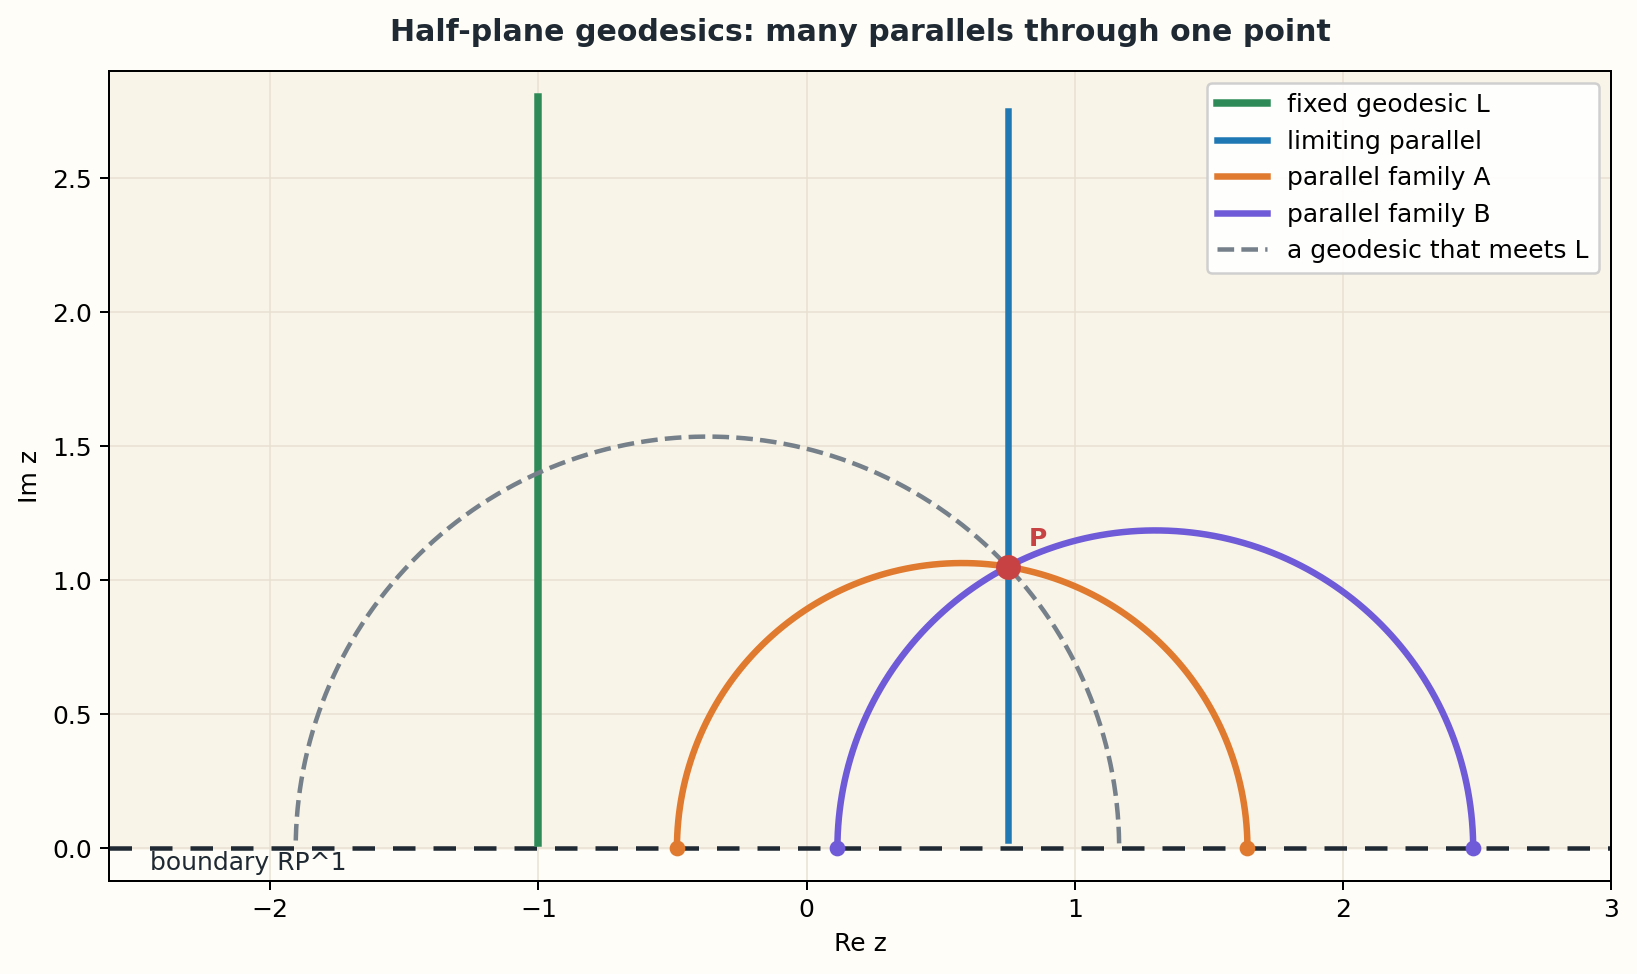

In [3]:
display_artifact(FIGURES["geodesics"], width=820)

## 2. Comparing the half-plane and disk models

The chapter's half-plane is not the only useful view. The Cayley transform

$$C(z)=\frac{z-i}{z+i}$$

moves the upper half-plane to the Poincare disk. This keeps angles visible: geodesics are still arcs that meet the boundary circle at right angles. A second radial projection sends the Poincare disk to the Klein disk. The Klein disk sacrifices conformality, but it makes every geodesic a Euclidean chord.

The same sample geodesics are drawn in all three models. The check attached to the figure verifies two things: Cayley preserves hyperbolic distance, and the Klein images of sampled geodesics are collinear to numerical tolerance.


In [4]:
def cayley(z):
    return (z - 1j) / (z + 1j)

def inverse_cayley(w):
    return 1j * (1 + w) / (1 - w)

def poincare_to_klein(w):
    w = np.asarray(w, dtype=complex)
    return 2 * w / (1 + np.abs(w) ** 2)

def hp_distance(z, w):
    arg = 1 + abs(z - w) ** 2 / (2 * z.imag * w.imag)
    return float(math.acosh(max(1.0, arg)))

def disk_distance(u, v):
    denom = (1 - abs(u) ** 2) * (1 - abs(v) ** 2)
    arg = 1 + 2 * abs(u - v) ** 2 / denom
    return float(math.acosh(max(1.0, arg)))

def draw_unit_disk(ax, title):
    ax.set_facecolor(PALETTE["paper"])
    ax.add_patch(Circle((0, 0), 1, fill=False, color=PALETTE["ink"], lw=1.8))
    ax.axhline(0, color="#d4c8b4", lw=0.8); ax.axvline(0, color="#d4c8b4", lw=0.8)
    ax.set_xlim(-1.08, 1.08); ax.set_ylim(-1.08, 1.08); ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, color=PALETTE["ink"], weight="bold"); ax.set_xticks([]); ax.set_yticks([])

sample_geodesics = [
    ("vertical", -0.65 + 1j * np.linspace(0.055, 4.4, 320), PALETTE["blue"]),
    ("unit semicircle", semicircle_points(0.0, 1.35, n=320), PALETTE["orange"]),
    ("shifted semicircle", semicircle_points(1.05, 0.95, n=320), PALETTE["purple"]),
]
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.4), facecolor=PALETTE["paper"])
setup_halfplane_axes(axes[0], xlim=(-2.2, 2.4), ylim=(-0.08, 3.0), title="Upper half-plane")
draw_unit_disk(axes[1], "Poincare disk"); draw_unit_disk(axes[2], "Klein disk")
for name, curve, color in sample_geodesics:
    plot_complex_curve(axes[0], curve, color=color, lw=2.3, label=name)
    disk_curve = cayley(curve); klein_curve = poincare_to_klein(disk_curve)
    plot_complex_curve(axes[1], disk_curve, color=color, lw=2.3)
    plot_complex_curve(axes[2], klein_curve, color=color, lw=2.3)
axes[0].legend(loc="upper right", frameon=True, facecolor="white", fontsize=9)
for ax, note in zip(axes, ["boundary is the real line", "angles are Euclidean angles", "geodesics are chords"]):
    ax.text(0.5, -0.11, note, transform=ax.transAxes, ha="center", va="top", color=PALETTE["gray"], fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES["models"], dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)
z_a, z_b = -0.4 + 0.9j, 1.1 + 1.4j
cayley_distance_error = abs(hp_distance(z_a, z_b) - disk_distance(cayley(z_a), cayley(z_b)))
klein_residuals = []
endpoint_pairs = [(-1.35, 1.35), (0.10, 2.00)]
for (name, curve, color), (e1, e2) in zip(sample_geodesics[1:], endpoint_pairs):
    k1, k2 = complex(cayley(e1 + 0j)), complex(cayley(e2 + 0j))
    pts = poincare_to_klein(cayley(curve[20:-20]))
    chord = np.array([k2.real-k1.real, k2.imag-k1.imag]); denom = np.linalg.norm(chord)
    signed = []
    for p0 in pts:
        v = np.array([p0.real-k1.real, p0.imag-k1.imag])
        signed.append(abs(chord[0]*v[1] - chord[1]*v[0]) / denom)
    klein_residuals.append(max(signed))
klein_collinearity_max = float(max(klein_residuals))
{"cayley_distance_error": cayley_distance_error, "klein_collinearity_max": klein_collinearity_max}


{'cayley_distance_error': 0.0,
 'klein_collinearity_max': 2.9545057261562876e-16}

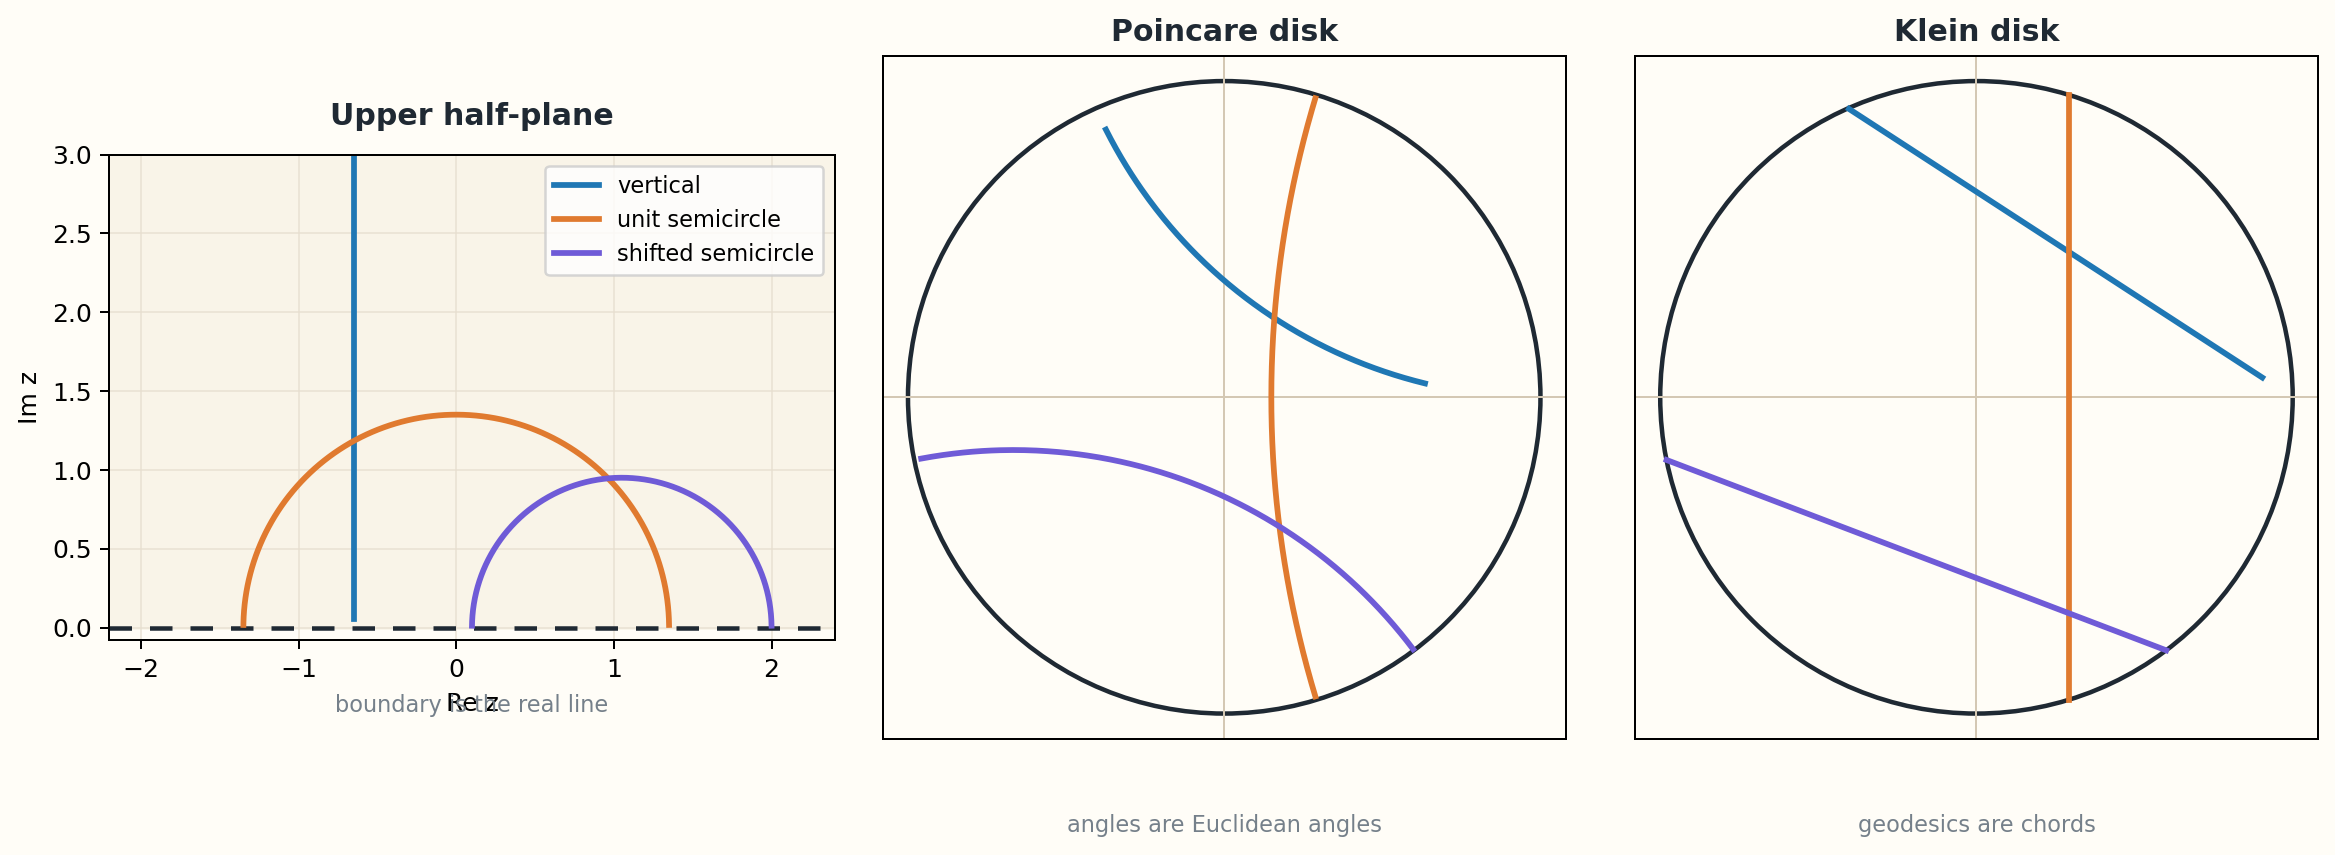

In [5]:
display_artifact(FIGURES["models"], width=900)

## 3. Mobius transformations as half-plane motions

For a real matrix $A=\begin{pmatrix}a&b\\c&d\end{pmatrix}$, the boundary action is the projective map $x\mapsto (ax+b)/(cx+d)$. The half-plane extension has one small but crucial rule.

If $ad-bc>0$, use $f(z)=(az+b)/(cz+d)$. If $ad-bc<0$, use $f(z)=(a\overline z+b)/(c\overline z+d)$. This explains why the boundary map $x\mapsto -x$ extends as reflection in the imaginary axis, $z\mapsto -\overline z$, rather than as $z\mapsto -z$.

The next figure applies a positive-determinant Mobius map to a rectangular half-plane grid. Lines bend, distances visibly change in Euclidean measurement, but the tiny angle check stays at 90 degrees because holomorphic Mobius maps are conformal. The Plotly lab underneath lets you switch among the generators used throughout the chapter.


In [6]:
def mobius(z, a, b, c, d):
    return (a * z + b) / (c * z + d)

def halfplane_extension(z, a, b, c, d):
    det = a * d - b * c
    zz = z if det > 0 else np.conjugate(z)
    return (a * zz + b) / (c * zz + d)

def angle_between_complex(u, v):
    cosang = np.real(u * np.conjugate(v)) / (abs(u) * abs(v))
    return float(np.arccos(np.clip(cosang, -1.0, 1.0)))

A = (1.2, -0.55, 0.25, 0.9)
def grid_curves():
    curves = []
    y = np.linspace(0.18, 3.4, 240)
    for x0 in np.linspace(-2.0, 2.0, 6):
        curves.append((x0 + 1j * y, PALETTE["blue"], 1.5))
    x = np.linspace(-2.35, 2.35, 260)
    for y0 in [0.25, 0.45, 0.8, 1.35, 2.25, 3.15]:
        curves.append((x + 1j * y0, PALETTE["orange"], 1.5))
    return curves

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.2), facecolor=PALETTE["paper"])
setup_halfplane_axes(axes[0], xlim=(-2.6, 2.6), ylim=(-0.12, 3.6), title="Before")
setup_halfplane_axes(axes[1], xlim=(-2.6, 2.6), ylim=(-0.12, 3.6), title="After a real Mobius map")
for curve, color, lw in grid_curves():
    plot_complex_curve(axes[0], curve, color=color, lw=lw, alpha=0.72)
    image = mobius(curve, *A)
    mask = (np.imag(image) > 0) & (np.abs(np.real(image)) < 20) & (np.abs(np.imag(image)) < 20)
    plot_complex_curve(axes[1], image[mask], color=color, lw=lw, alpha=0.85)
z0 = 0.35 + 1.15j; fz0 = mobius(z0, *A)
det_A = A[0] * A[3] - A[1] * A[2]
derivative = det_A / (A[2] * z0 + A[3]) ** 2
u = derivative; v = 1j * derivative
conformal_angle_error_degrees = abs(math.degrees(angle_between_complex(u, v)) - 90.0)
axes[0].scatter([z0.real], [z0.imag], s=65, color=PALETTE["red"], zorder=5)
axes[1].scatter([fz0.real], [fz0.imag], s=65, color=PALETTE["red"], zorder=5)
axes[1].text(-2.45, 3.35, f"local angle error: {conformal_angle_error_degrees:.2e} deg", color=PALETTE["ink"], fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES["mobius_grid"], dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

base_curves = [("vertical", -0.7 + 1j*np.linspace(0.06, 3.8, 180)), ("semicircle", semicircle_points(0.35, 1.15, n=180)), ("shifted", semicircle_points(1.45, 0.85, n=180))]
transforms = [("identity", lambda z: z), ("translation z+1", lambda z: z + 1), ("dilation 1.6z", lambda z: 1.6 * z), ("half-turn -1/z", lambda z: -1 / z)]
fig_lab = go.Figure(); trace_groups = []
for idx, (label, fn) in enumerate(transforms):
    group = []
    for curve_name, curve in base_curves:
        image = fn(curve); group.append(len(fig_lab.data))
        fig_lab.add_trace(go.Scatter(x=np.real(image), y=np.imag(image), mode="lines", name=f"{label}: {curve_name}", line={"width":3}, visible=(idx==0), hovertemplate="Re=%{x:.3f}<br>Im=%{y:.3f}<extra></extra>"))
    trace_groups.append(group)
buttons = []
for idx, (label, _) in enumerate(transforms):
    visible = [False] * len(fig_lab.data)
    for trace_index in trace_groups[idx]:
        visible[trace_index] = True
    buttons.append({"label":label, "method":"update", "args":[{"visible":visible}, {"title":f"Half-plane geodesics under {label}"}]})
fig_lab.update_layout(title="Half-plane geodesics under identity", xaxis_title="Re z", yaxis_title="Im z", template="plotly_white", width=900, height=520, updatemenus=[{"buttons":buttons, "direction":"down", "x":0.02, "y":1.15}], xaxis={"scaleanchor":"y", "range":[-3,3]}, yaxis={"range":[0,4]})
fig_lab.write_html(HTML["mobius_lab"], include_plotlyjs=True, full_html=True)
mobius_sample_rows = []
for label, fn in transforms:
    z, w = 0.4 + 1.2j, 1.1 + 1.8j
    mobius_sample_rows.append({"transformation":label, "distance_before":hp_distance(z,w), "distance_after":hp_distance(fn(z), fn(w)), "absolute_error":abs(hp_distance(z,w)-hp_distance(fn(z),fn(w)))})
save_table(mobius_sample_rows, ARTIFACT_ROOT, "tables", "mobius-samples.csv")
{"conformal_angle_error_degrees": conformal_angle_error_degrees, "mobius_samples": mobius_sample_rows}


{'conformal_angle_error_degrees': 0.0,
 'mobius_samples': [{'transformation': 'identity',
   'distance_before': 0.6174551396878188,
   'distance_after': 0.6174551396878188,
   'absolute_error': 0.0},
  {'transformation': 'translation z+1',
   'distance_before': 0.6174551396878188,
   'distance_after': 0.6174551396878188,
   'absolute_error': 0.0},
  {'transformation': 'dilation 1.6z',
   'distance_before': 0.6174551396878188,
   'distance_after': 0.6174551396878188,
   'absolute_error': 0.0},
  {'transformation': 'half-turn -1/z',
   'distance_before': 0.6174551396878188,
   'distance_after': 0.6174551396878188,
   'absolute_error': 0.0}]}

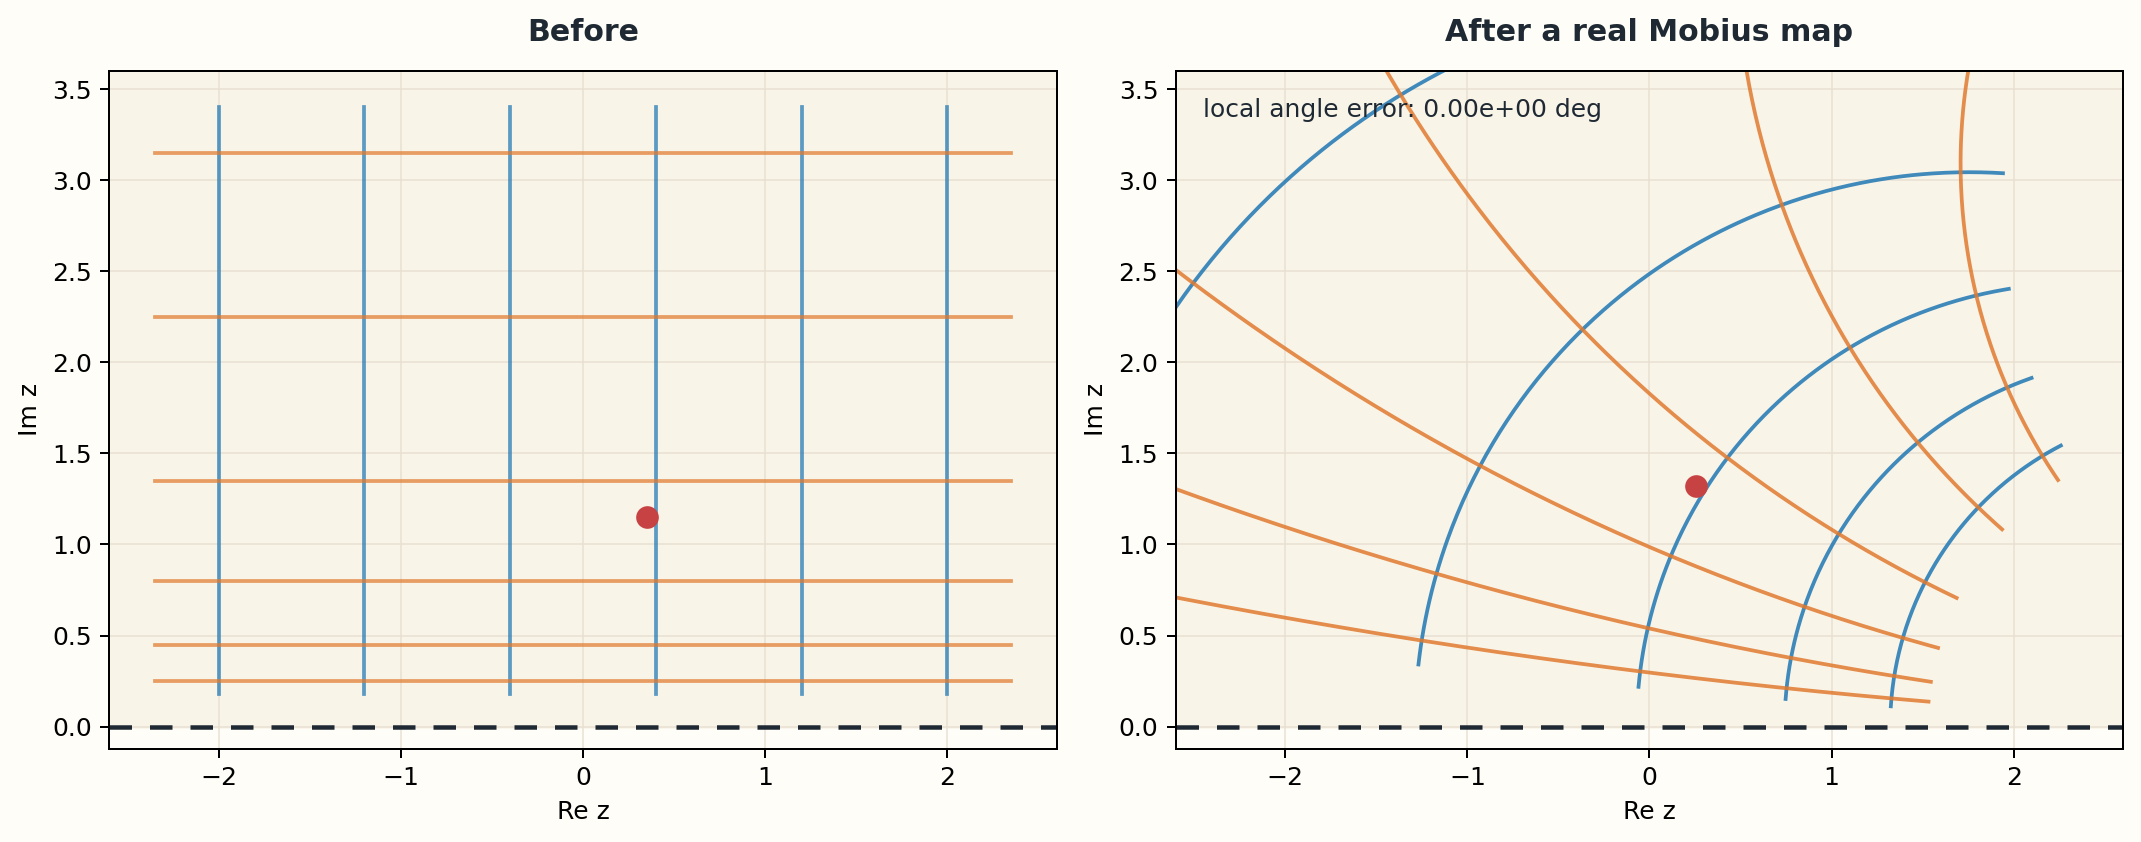

In [7]:
display_artifact(FIGURES["mobius_grid"], width=880)
display_artifact(HTML["mobius_lab"], width="100%", height=560)

## 4. Reflections and factorization

A hyperbolic reflection fixes one geodesic pointwise. In the half-plane model these reflections have simple formulas:

- reflection in the vertical geodesic $x=a$: $z\mapsto 2a-\overline z$,
- reflection in the semicircle with center $c$ and radius $r$: $z\mapsto c+r^2/(\overline z-c)$.

Products of two reflections recover the familiar orientation-preserving Mobius maps. Two vertical reflections give a translation. Two concentric circle reflections give a dilation. A vertical reflection followed by a unit-circle reflection gives the half-turn $z\mapsto -1/z$. The proof map below also shows the source-specific theorem route: projective three-point uniqueness leads to the two-involutions theorem on $\mathbb{RP}^1$, and that lifts to at most three half-plane reflections.


In [8]:
def reflect_vertical(z, a=0.0):
    return 2*a - np.conjugate(z)

def reflect_circle(z, center=0.0, radius=1.0):
    return center + radius**2 / (np.conjugate(z) - center)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.2), facecolor=PALETTE["paper"])
setup_halfplane_axes(axes[0], xlim=(-1.7, 1.9), ylim=(-0.1, 2.2), title="Reflection in a semicircle geodesic")
plot_complex_curve(axes[0], semicircle_points(0.0, 1.0), PALETTE["green"], lw=3.0, label="fixed geodesic")
for z in np.array([-0.55 + 1.35j, 0.25 + 1.55j, 0.82 + 1.25j]):
    rz = reflect_circle(z)
    axes[0].plot([z.real, rz.real], [z.imag, rz.imag], color=PALETTE["gray"], lw=1.3, linestyle="--")
    axes[0].scatter([z.real], [z.imag], color=PALETTE["blue"], s=55, zorder=5)
    axes[0].scatter([rz.real], [rz.imag], color=PALETTE["red"], s=55, zorder=5)
axes[0].legend(loc="upper right", frameon=True, facecolor="white")
axes[1].axis("off"); axes[1].set_title("Products of reflections", color=PALETTE["ink"], weight="bold", pad=12)
boxes = [(0.05,0.78,"R_0(z)= -conj(z)\nreflect in y-axis"),(0.55,0.78,"R_{1/2}(z)=1-conj(z)\nsecond vertical reflection"),(0.32,0.56,"R_{1/2} o R_0: z -> z+1\nhyperbolic translation"),(0.05,0.33,"C_1(z)=1/conj(z)\nunit-circle reflection"),(0.55,0.33,"C_s(z)=s^2/conj(z)\nconcentric circle reflection"),(0.32,0.11,"C_s o C_1: z -> s^2 z\ndilation along the y-axis")]
for x0, y0, text in boxes:
    axes[1].text(x0, y0, text, transform=axes[1].transAxes, ha="left", va="center", fontsize=10, bbox={"boxstyle":"round,pad=0.35","facecolor":"white","edgecolor":"#d5c8b3"})
for start, end in [((0.27,0.73),(0.38,0.61)),((0.68,0.73),(0.52,0.61)),((0.27,0.28),(0.38,0.16)),((0.68,0.28),(0.52,0.16))]:
    axes[1].annotate("", xy=end, xytext=start, xycoords="axes fraction", textcoords="axes fraction", arrowprops={"arrowstyle":"->","lw":1.8,"color":PALETTE["gray"]})
fig.tight_layout()
fig.savefig(FIGURES["reflections"], dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

G = nx.DiGraph()
edges = [("three-point\nuniqueness","four-point\ncriterion"),("four-point\ncriterion","two involutions\non RP^1"),("two involutions\non RP^1","involutions exchange\ngeodesic ends"),("involutions exchange\ngeodesic ends","fixed point\non geodesic"),("angle preservation","perpendicular\naxis"),("fixed point\non geodesic","perpendicular\naxis"),("perpendicular\naxis","reflection or\ntwo reflections"),("reflection or\ntwo reflections","at most three\nreflections")]
G.add_edges_from(edges)
pos = {"three-point\nuniqueness":(0,2.2),"four-point\ncriterion":(1.25,2.2),"two involutions\non RP^1":(2.5,2.2),"involutions exchange\ngeodesic ends":(2.5,1.25),"fixed point\non geodesic":(1.25,0.75),"angle preservation":(0,0.75),"perpendicular\naxis":(1.25,-0.1),"reflection or\ntwo reflections":(2.5,-0.1),"at most three\nreflections":(3.75,-0.1)}
fig, ax = plt.subplots(figsize=(10.5, 5.3), facecolor=PALETTE["paper"])
ax.set_facecolor(PALETTE["paper"])
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#8a8174")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2800, node_color="#fff8eb", edgecolors=PALETTE["ink"], linewidths=1.3)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color=PALETTE["ink"])
ax.set_title("Proof scaffold: from projective involutions to half-plane reflections", color=PALETTE["ink"], weight="bold")
ax.axis("off"); fig.tight_layout()
fig.savefig(FIGURES["proof_map"], dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

z_test = 0.42 + 1.37j
reflection_checks = {
    "circle_reflection_involution_error": float(abs(reflect_circle(reflect_circle(z_test)) - z_test)),
    "vertical_reflection_translation_error": float(abs(reflect_vertical(reflect_vertical(z_test, 0.0), 0.5) - (z_test + 1))),
    "circle_reflection_dilation_error": float(abs(reflect_circle(reflect_circle(z_test, 0.0, 1.0), 0.0, math.sqrt(1.8)) - 1.8 * z_test)),
    "half_turn_factorization_error": float(abs(reflect_circle(reflect_vertical(z_test, 0.0), 0.0, 1.0) - (-1 / z_test))),
}
reflection_checks


{'circle_reflection_involution_error': 0.0,
 'vertical_reflection_translation_error': 0.0,
 'circle_reflection_dilation_error': 1.1102230246251565e-16,
 'half_turn_factorization_error': 2.7755575615628914e-17}

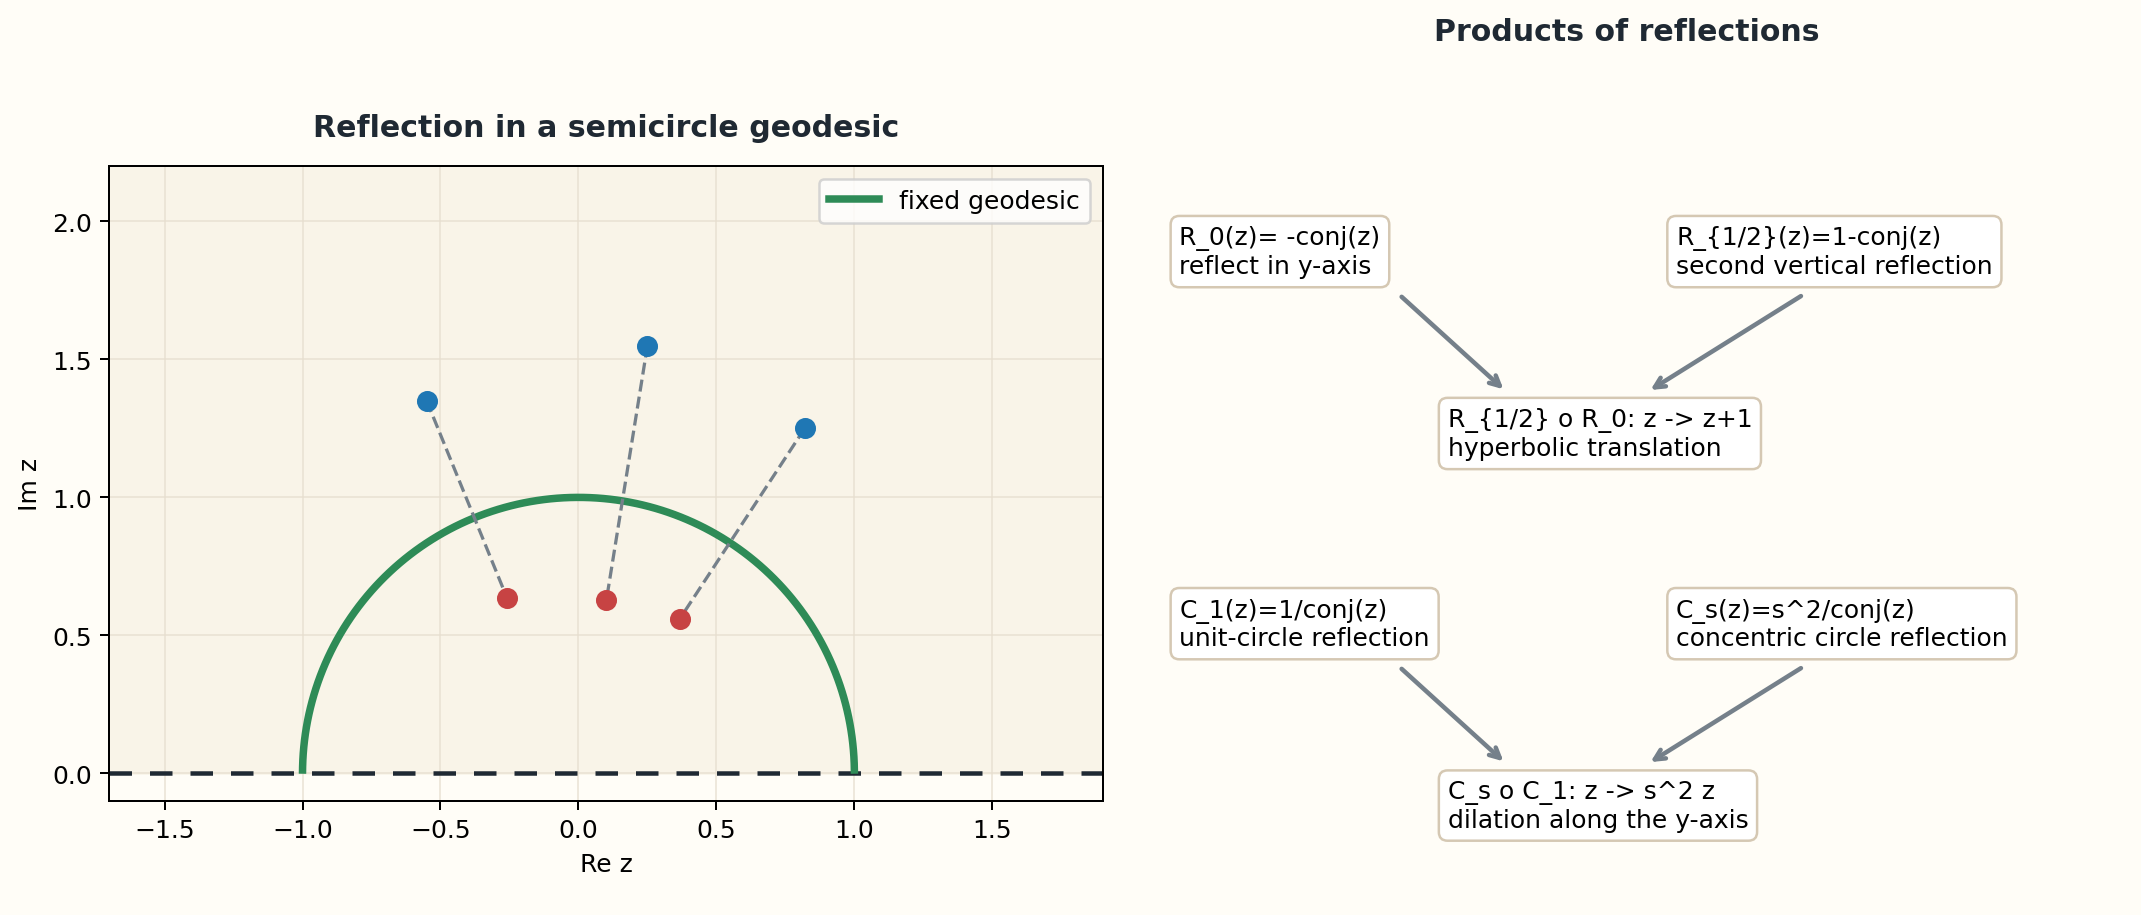

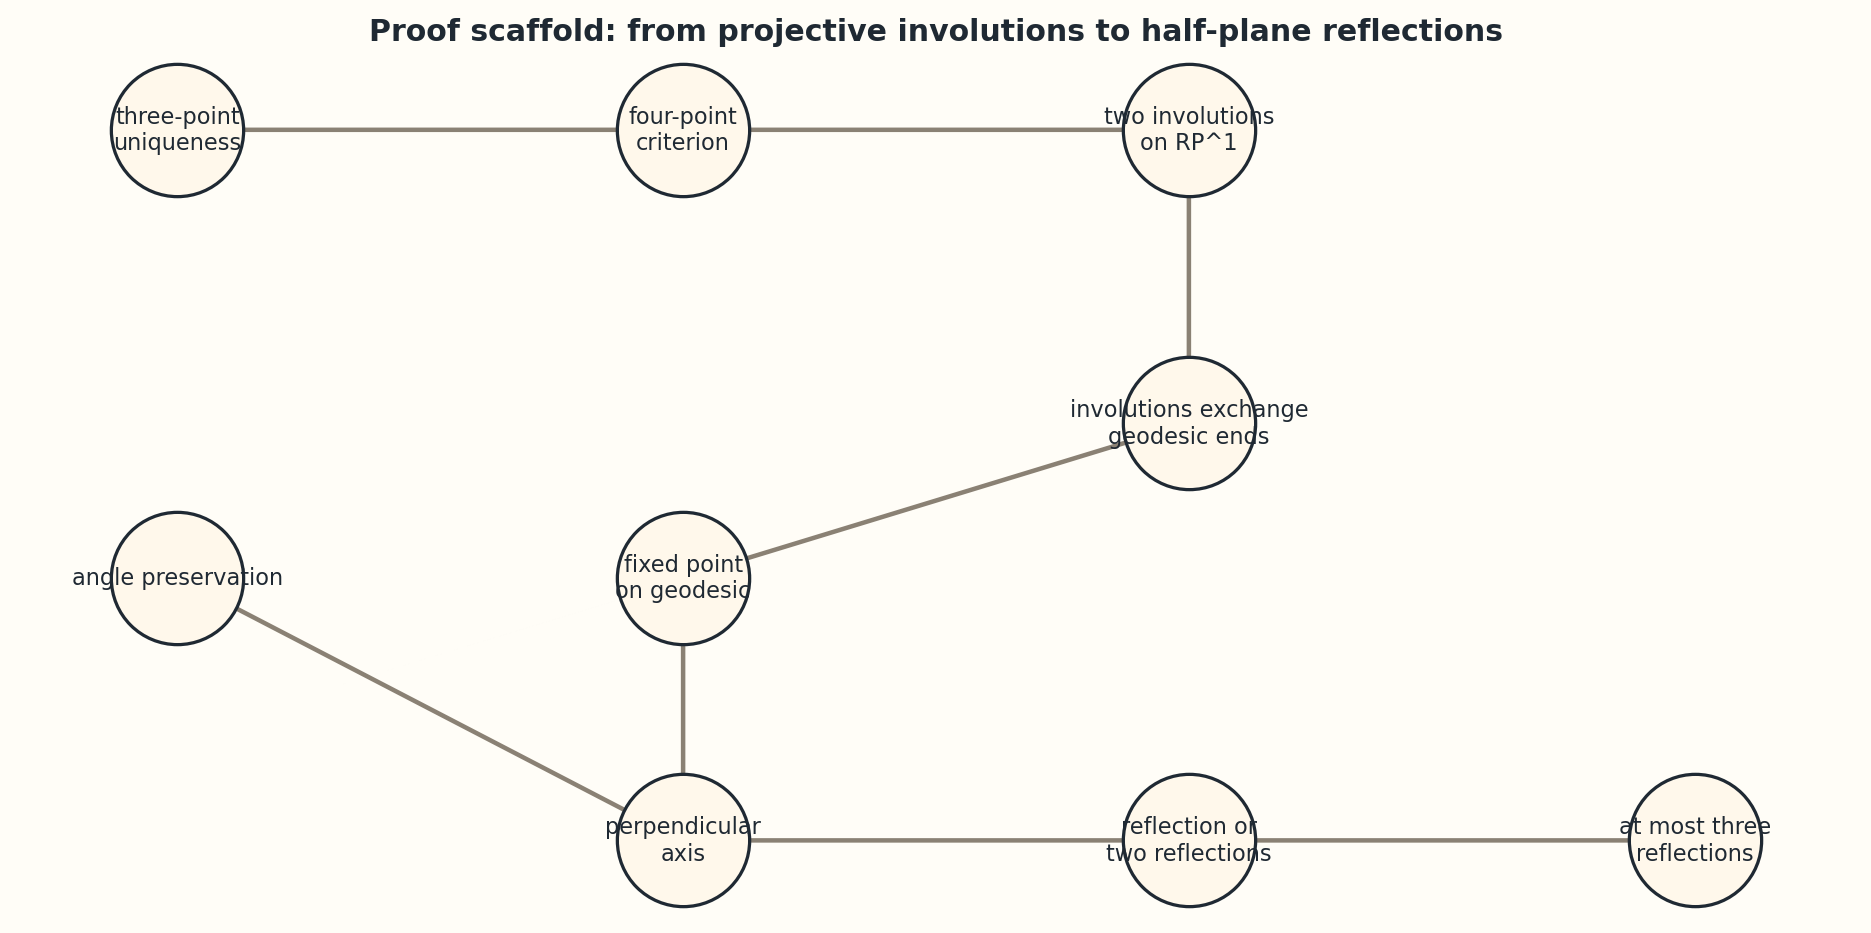

In [9]:
display_artifact(FIGURES["reflections"], width=880)
display_artifact(FIGURES["proof_map"], width=880)

## 5. Distance from cross-ratio

The cross-ratio is still the algebraic invariant, but distance needs two points rather than four. A geodesic supplies the missing two: its boundary endpoints. On the upper $y$-axis the endpoints are $0$ and $\infty$, and the cross-ratio collapses to a ratio of heights. This gives

$$d_H(pi,qi)=\left|\log\frac{q}{p}\right|.$$

The full half-plane formula used below is equivalent and is invariant under the same real Mobius transformations. The heatmaps show distance from $i$ in the half-plane and from $0$ in the Poincare disk. The marked points $2^n i$ are equally spaced even though their Euclidean gaps double upward and shrink toward the boundary downward.


In [10]:
xs = np.linspace(-2.6, 2.6, 240); ys = np.linspace(0.08, 3.6, 210)
X, Y = np.meshgrid(xs, ys); Z = X + 1j * Y; base = 1j
D = np.arccosh(1 + np.abs(Z - base) ** 2 / (2 * Y * base.imag)); D = np.clip(D, 0, 4.0)
u = np.linspace(-0.97, 0.97, 240); v = np.linspace(-0.97, 0.97, 240)
U, V = np.meshgrid(u, v); R2 = U**2 + V**2
DD = np.full_like(R2, np.nan, dtype=float); mask = R2 < 0.97**2
DD[mask] = 2 * np.arctanh(np.sqrt(R2[mask])); DD = np.clip(DD, 0, 4.0)
fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2), facecolor=PALETTE["paper"])
setup_halfplane_axes(axes[0], xlim=(-2.6, 2.6), ylim=(-0.1, 3.6), title="Distance from i in the half-plane")
im = axes[0].contourf(X, Y, D, levels=np.linspace(0,4,17), cmap="viridis")
axes[0].contour(X, Y, D, levels=[0.5,1,1.5,2,2.5,3], colors="white", linewidths=0.8, alpha=0.8)
heights = np.array([2.0**n for n in range(-3, 3)])
axes[0].scatter(np.zeros_like(heights), heights, color=PALETTE["red"], s=40, zorder=5)
for h in heights:
    if h <= 3.6: axes[0].text(0.08, h, f"{h:g}i", color=PALETTE["red"], fontsize=8, va="center")
axes[0].scatter([0], [1], color="white", edgecolor=PALETTE["ink"], s=75, zorder=6)
axes[1].set_facecolor(PALETTE["paper"]); axes[1].add_patch(Circle((0,0), 1, fill=False, color=PALETTE["ink"], lw=1.8))
axes[1].contourf(U, V, DD, levels=np.linspace(0,4,17), cmap="viridis")
axes[1].contour(U, V, DD, levels=[0.5,1,1.5,2,2.5,3], colors="white", linewidths=0.8, alpha=0.8)
axes[1].scatter([0], [0], color="white", edgecolor=PALETTE["ink"], s=75, zorder=6)
axes[1].set_xlim(-1.05,1.05); axes[1].set_ylim(-1.05,1.05); axes[1].set_aspect("equal", adjustable="box")
axes[1].set_title("Distance from 0 in the Poincare disk", color=PALETTE["ink"], weight="bold")
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82, label="hyperbolic distance")
fig.savefig(FIGURES["distance"], dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

fig_dist = go.Figure(data=go.Heatmap(x=xs, y=ys, z=D, colorscale="Viridis", zmin=0, zmax=4, colorbar={"title":"d_H(z,i)"}, hovertemplate="x=%{x:.3f}<br>y=%{y:.3f}<br>d=%{z:.3f}<extra></extra>"))
fig_dist.add_trace(go.Scatter(x=[0], y=[1], mode="markers+text", text=["i"], textposition="top right", marker={"size":10,"color":"white","line":{"color":"black","width":1}}, name="base point"))
fig_dist.add_trace(go.Scatter(x=np.zeros_like(heights), y=heights, mode="markers", marker={"size":8,"color":"red"}, name="2^n i"))
fig_dist.update_layout(title="Hyperbolic distance from i; hover to read the metric value", xaxis_title="Re z", yaxis_title="Im z", template="plotly_white", width=900, height=560, xaxis={"scaleanchor":"y","range":[-2.6,2.6]}, yaxis={"range":[0,3.6]})
fig_dist.write_html(HTML["distance_lab"], include_plotlyjs=True, full_html=True)
axis_rows = []
for p0, q0 in [(1,2),(2,4),(0.5,4),(0.25,2)]:
    axis_rows.append({"point_a":f"{p0}i","point_b":f"{q0}i","distance_formula":hp_distance(1j*p0,1j*q0),"log_ratio":abs(math.log(q0/p0)),"absolute_error":abs(hp_distance(1j*p0,1j*q0)-abs(math.log(q0/p0)))})
save_table(axis_rows, ARTIFACT_ROOT, "tables", "distance-samples.csv")
axis_log_error = max(row["absolute_error"] for row in axis_rows)
distance_additivity_error = abs(hp_distance(1j,4j) - (hp_distance(1j,2j) + hp_distance(2j,4j)))
T = lambda z: mobius(z, 1.2, -0.55, 0.25, 0.9)
z1, z2 = -0.2 + 0.8j, 1.25 + 1.35j
mobius_distance_error = abs(hp_distance(z1,z2) - hp_distance(T(z1), T(z2)))
{"axis_log_error": axis_log_error, "distance_additivity_error": distance_additivity_error, "mobius_distance_error": mobius_distance_error}


{'axis_log_error': 0.0,
 'distance_additivity_error': 0.0,
 'mobius_distance_error': 2.220446049250313e-16}

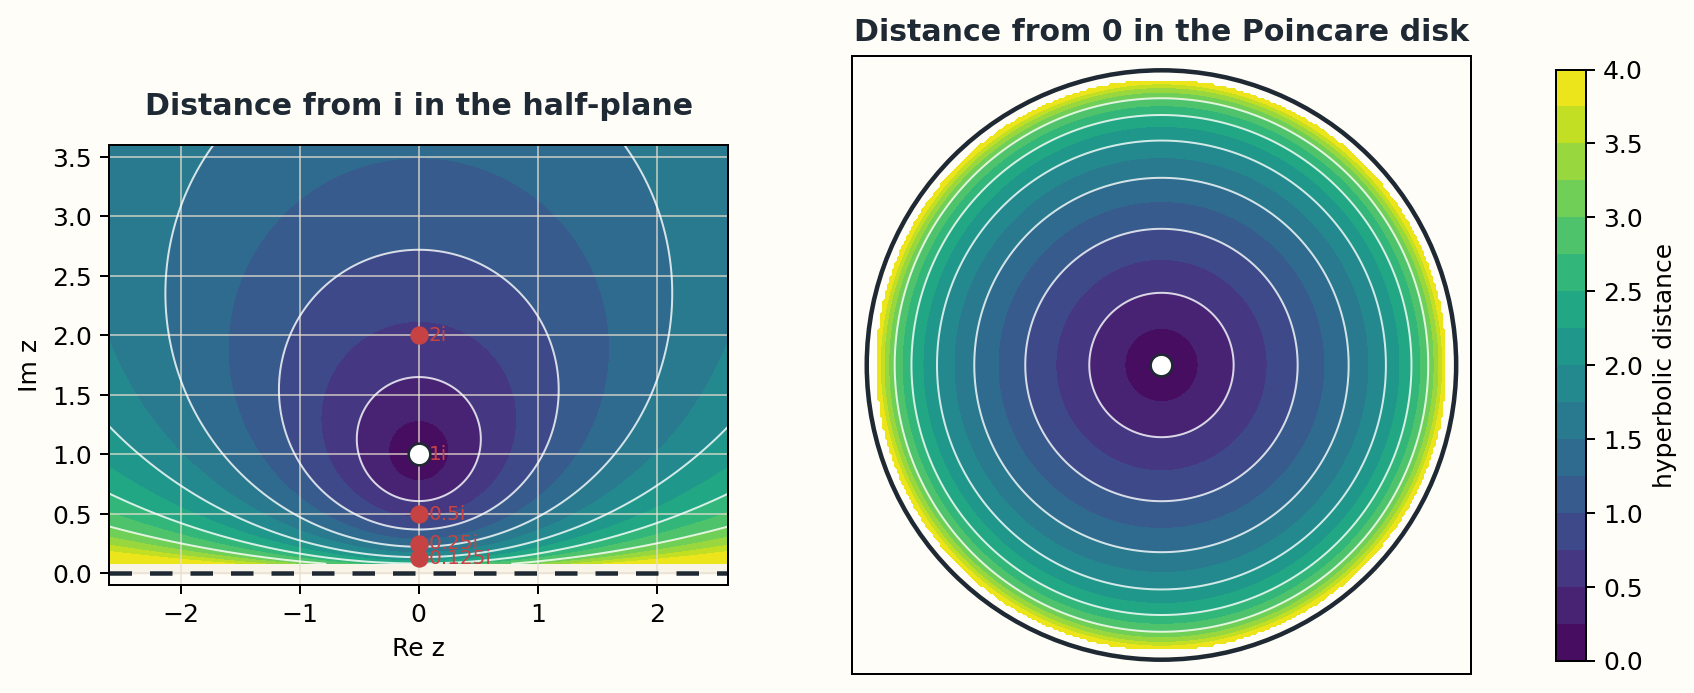

In [11]:
display_artifact(FIGURES["distance"], width=880)
display_artifact(HTML["distance_lab"], width="100%", height=560)
display_artifact(TABLES["distance_samples"])

## 6. Algebraic invariants behind the visuals

The figures are useful only if they are connected to invariants. This cell records the main checks in executable form.

- The cross-ratio is unchanged by a real linear fractional transformation.
- For positive determinant, the imaginary part satisfies
  $$\operatorname{Im}\frac{az+b}{cz+d}=\frac{(ad-bc)\operatorname{Im}z}{|cz+d|^2},$$
  so the upper half-plane maps to itself.
- The Cayley transform agrees with the Poincare disk metric.
- Reflections square to the identity, and selected products match translations, dilations, and half-turns.


In [12]:
a, b, c, d, p, q, r, s, x, y = sp.symbols("a b c d p q r s x y", real=True)
def cr_expr(A0, B0, C0, D0):
    return ((A0-C0)*(B0-D0))/((A0-D0)*(B0-C0))
f = lambda t: (a*t+b)/(c*t+d)
cross_ratio_identity = sp.factor(sp.together(cr_expr(f(p), f(q), f(r), f(s)) - cr_expr(p, q, r, s))) == 0
I = sp.I; z = x + I*y
num = sp.expand((a*z+b) * (c*sp.conjugate(z)+d))
denom = (c*x+d)**2 + (c*y)**2
imag_coeff = sp.expand(num).coeff(I)
imaginary_part_identity = sp.simplify(imag_coeff/denom - (a*d-b*c)*y/denom) == 0
negative_extension_test = halfplane_extension(0.4 + 1.3j, -1, 0, 0, 1)
negative_extension_error = abs(negative_extension_test - (-np.conjugate(0.4 + 1.3j)))
invariants = {
    "source_span":{"printed_pages":"174-212","pdf_pages":"184-222","sections":"8.1-8.9"},
    "cross_ratio_identity_sympy":bool(cross_ratio_identity),
    "imaginary_part_identity_sympy":bool(imaginary_part_identity),
    "axis_log_distance_max_error":float(axis_log_error),
    "distance_additivity_error":float(distance_additivity_error),
    "mobius_distance_error":float(mobius_distance_error),
    "cayley_distance_error":float(cayley_distance_error),
    "klein_collinearity_max_error":float(klein_collinearity_max),
    "conformal_angle_error_degrees":float(conformal_angle_error_degrees),
    "negative_determinant_extension_error":float(negative_extension_error),
    **reflection_checks,
    "parallel_geodesic_checks":parallel_checks,
}
save_json(invariants, ARTIFACT_ROOT, "checks", "chapter-08-invariants.json")
invariants


{'source_span': {'printed_pages': '174-212',
  'pdf_pages': '184-222',
  'sections': '8.1-8.9'},
 'cross_ratio_identity_sympy': True,
 'imaginary_part_identity_sympy': True,
 'axis_log_distance_max_error': 0.0,
 'distance_additivity_error': 0.0,
 'mobius_distance_error': 2.220446049250313e-16,
 'cayley_distance_error': 0.0,
 'klein_collinearity_max_error': 2.9545057261562876e-16,
 'conformal_angle_error_degrees': 0.0,
 'negative_determinant_extension_error': 0.0,
 'circle_reflection_involution_error': 0.0,
 'vertical_reflection_translation_error': 0.0,
 'circle_reflection_dilation_error': 1.1102230246251565e-16,
 'half_turn_factorization_error': 2.7755575615628914e-17,
 'parallel_geodesic_checks': [{'center': 0.58,
   'radius': 1.0636728820459793,
   'contains_P_residual': 0.0,
   'left_endpoint_minus_fixed_x': 0.5163271179540206},
  {'center': 1.3,
   'radius': 1.1853269591129698,
   'contains_P_residual': 0.0,
   'left_endpoint_minus_fixed_x': 1.1146730408870302}]}

## Applied exploration: diagnose a proposed half-plane transformation

The function below is a small lab for testing a real boundary matrix. Change the four entries and rerun the cell. The output tells you whether the determinant is positive or negative, whether the half-plane extension keeps sample points above the boundary, and how much hyperbolic distance changes on a sample pair.

This is a practical translation of the chapter's main habit: a proposed geometry is not defined by how a picture looks, but by which transformations and invariants it protects.


In [13]:
def diagnose_boundary_matrix(a, b, c, d, z=0.25 + 0.9j, w=1.05 + 1.4j):
    det = a*d - b*c
    if abs(det) < 1e-12:
        raise ValueError("The boundary matrix is singular and does not define a projective transformation.")
    fz, fw = halfplane_extension(z, a, b, c, d), halfplane_extension(w, a, b, c, d)
    return {"determinant":float(det), "extension_type":"orientation preserving" if det > 0 else "orientation reversing reflection-type", "image_Im_z":float(np.imag(fz)), "image_Im_w":float(np.imag(fw)), "distance_before":hp_distance(z,w), "distance_after":hp_distance(fz,fw), "distance_error":abs(hp_distance(z,w)-hp_distance(fz,fw))}

sample_diagnostics = [
    diagnose_boundary_matrix(1, 1, 0, 1),
    diagnose_boundary_matrix(2, 0, 0, 1),
    diagnose_boundary_matrix(0, -1, 1, 0),
    diagnose_boundary_matrix(-1, 0, 0, 1),
]
sample_diagnostics


[{'determinant': 1.0,
  'extension_type': 'orientation preserving',
  'image_Im_z': 0.9,
  'image_Im_w': 1.4,
  'distance_before': 0.8174914538148785,
  'distance_after': 0.8174914538148783,
  'distance_error': 2.220446049250313e-16},
 {'determinant': 2.0,
  'extension_type': 'orientation preserving',
  'image_Im_z': 1.8,
  'image_Im_w': 2.8,
  'distance_before': 0.8174914538148785,
  'distance_after': 0.8174914538148785,
  'distance_error': 0.0},
 {'determinant': 1.0,
  'extension_type': 'orientation preserving',
  'image_Im_z': 1.0315186246418337,
  'image_Im_w': 0.45714285714285713,
  'distance_before': 0.8174914538148785,
  'distance_after': 0.8174914538148785,
  'distance_error': 0.0},
 {'determinant': -1.0,
  'extension_type': 'orientation reversing reflection-type',
  'image_Im_z': 0.9,
  'image_Im_w': 1.4,
  'distance_before': 0.8174914538148785,
  'distance_after': 0.8174914538148785,
  'distance_error': 0.0}]

## Final sanity checks

The final cell checks both the mathematics and the generated files. The thresholds are intentionally tight for algebraic identities and loose enough for floating point geometry. If one of these assertions fails, the corresponding visual should not be trusted until the mismatch is understood.


In [14]:
manifest = {
    "figures":[path.relative_to(BOOK_ROOT).as_posix() for path in FIGURES.values()],
    "html":[path.relative_to(BOOK_ROOT).as_posix() for path in HTML.values()],
    "checks":[path.relative_to(BOOK_ROOT).as_posix() for path in CHECKS.values()],
    "tables":[path.relative_to(BOOK_ROOT).as_posix() for path in TABLES.values()],
}
save_json(manifest, ARTIFACT_ROOT, "checks", "artifact-manifest.json")
all_artifacts = list(FIGURES.values()) + list(HTML.values()) + list(CHECKS.values()) + list(TABLES.values())
assert_artifacts(all_artifacts, min_size=128)
figure_stats = [image_stats(path) for path in FIGURES.values()]
assert all(item["width"] >= 300 and item["height"] >= 240 for item in figure_stats)
assert all(item["pixel_std"] > 2.0 for item in figure_stats)
assert invariants["cross_ratio_identity_sympy"]
assert invariants["imaginary_part_identity_sympy"]
assert invariants["axis_log_distance_max_error"] < 1e-12
assert invariants["distance_additivity_error"] < 1e-12
assert invariants["mobius_distance_error"] < 1e-12
assert invariants["cayley_distance_error"] < 1e-12
assert invariants["klein_collinearity_max_error"] < 1e-10
assert invariants["conformal_angle_error_degrees"] < 1e-5
for key in ["circle_reflection_involution_error", "vertical_reflection_translation_error", "circle_reflection_dilation_error", "half_turn_factorization_error"]:
    assert invariants[key] < 1e-12
assert all(item["left_endpoint_minus_fixed_x"] > 0 for item in invariants["parallel_geodesic_checks"])
assert all(row["distance_error"] < 1e-12 and row["image_Im_z"] > 0 and row["image_Im_w"] > 0 for row in sample_diagnostics)
print("Chapter 8 non-Euclidean geometry checks passed.")
print(json.dumps({"figure_count":len(FIGURES), "html_labs":len(HTML), "max_png_std":max(item["pixel_std"] for item in figure_stats)}, indent=2))


Chapter 8 non-Euclidean geometry checks passed.
{
  "figure_count": 6,
  "html_labs": 2,
  "max_png_std": 83.23535007074706
}


## Takeaways

- The upper half-plane turns the projective line into a visible boundary geometry: endpoints on $\mathbb{RP}^1$ control the interior geodesics.
- Hyperbolic lines are vertical rays or boundary-orthogonal semicircles, so the Euclidean parallel axiom fails while the rest of the line behavior remains coherent.
- Real Mobius transformations preserve the half-plane once determinant sign is handled correctly; positive determinant maps are conformal, and negative determinant maps are reflection-type extensions.
- Reflections in geodesics generate the important motions: translations, dilations, half-turns, and, by the projective involution argument, arbitrary half-plane Mobius isometries with at most three reflections.
- Hyperbolic distance is a cross-ratio idea made visible. On the vertical ruler it is logarithmic, and the Cayley transform carries the same distance into the Poincare disk.
